# Deliverable 2: Bayesian Search Strategy
## Gemini Implementation

This notebook implements the Bayesian Search theory to find a missing object after an accident, as requested in Deliverable 2.

We will go through the following steps:
1. **Prior Construction**: Using the accident location, physical vectors, and witnesses to build a prior distribution.
2. **Detection Model**: Defining the conditional probability of detection based on effort, depth, and roughness.
3. **Posterior Update**: Defining how our beliefs update after search missions.
4. **Next Search Mission**: Strategy for proposing new search boundaries based on the posterior distribution.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Grid dimensions
Nx = 50
Ny = 35

# Load the fixed grid dataset
grid_df = pd.read_csv("../grid_dataset.csv")

# Accident location
Bx = 7
By = 20
x_E = np.array([Bx, By])

# Physical vectors
v_plane = np.array([6.0, -3.5])
v_wind  = np.array([-1.0, -1.5])
v_drift = np.array([0.5, -1.5])

print("Accident location:", x_E)
print("Plane velocity:", v_plane)
print("Wind:", v_wind)
print("Drift:", v_drift)


Accident location: [ 7 20]
Plane velocity: [ 6.  -3.5]
Wind: [-1.  -1.5]
Drift: [ 0.5 -1.5]


## Task 1: Prior Construction

**Justification:**
The accident happened at $(7, 20)$. Witness 1 stated that the object kept moving roughly in the general direction of the aircraft. Witness 2 stated it fell farther along the trajectory, slightly off to one side.
We can model the expected drop location $\mu$ as a linear combination of the vectors.
- Let's assume the object traveled for a time $t_1=1.5$ influenced heavily by the plane velocity.
- The object was also affected by wind ($t_2=1.0$) and drift ($t_3=1.0$).
So:
$$\mu = x_E + 1.5 \cdot v_{plane} + 1.0 \cdot v_{wind} + 1.0 \cdot v_{drift}$$

We will use a Bivariate Normal distribution centered at $\mu$ with a covariance matrix $\Sigma = \egin{bmatrix} 40 & 0 \\ 0 & 40 \end{bmatrix}$ to represent the uncertainty around this expected point. The probabilities will be evaluated at the center of each cell and normalized so that $\sum \pi_j = 1$.


In [2]:
# Calculate expected center
mu = x_E + 1.5 * v_plane + 1.0 * v_wind + 1.0 * v_drift

# Covariance matrix (uncertainty)
Sigma = np.array([[40, 0], 
                  [0, 40]])

# Create Multivariate Normal
rv = multivariate_normal(mean=mu, cov=Sigma)

# Compute prior for each cell
grid_df['prior'] = rv.pdf(grid_df[['x', 'y']].values)

# Normalize the prior to sum exactly to 1
grid_df['prior'] = grid_df['prior'] / grid_df['prior'].sum()

print(f"Expected center point (mu): {mu}")
print(f"Sum of prior probabilities: {grid_df['prior'].sum():.4f}")


Expected center point (mu): [15.5  11.75]
Sum of prior probabilities: 1.0000


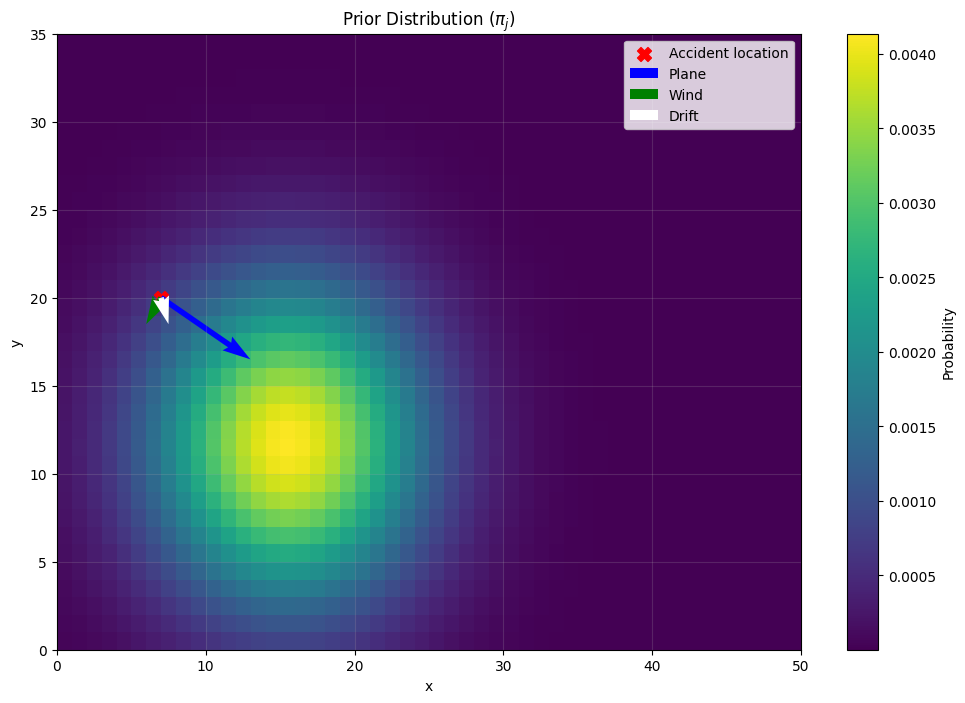

In [3]:
# Function to plot heatmaps
def plot_heatmap(df, column, title):
    # Pivot table to get the 2D grid
    grid_matrix = df.pivot(index='y', columns='x', values=column).values
    
    plt.figure(figsize=(12, 8))
    plt.imshow(grid_matrix, origin='lower', extent=[0, Nx, 0, Ny], cmap='viridis', aspect='auto')
    plt.colorbar(label='Probability')
    
    # Plot vectors and accident location
    plt.scatter(x_E[0], x_E[1], color="red", s=100, label="Accident location", marker='X')
    plt.quiver(x_E[0], x_E[1], v_plane[0], v_plane[1], angles="xy", scale_units="xy", scale=1, color="blue", label="Plane")
    plt.quiver(x_E[0], x_E[1], v_wind[0], v_wind[1], angles="xy", scale_units="xy", scale=1, color="green", label="Wind")
    plt.quiver(x_E[0], x_E[1], v_drift[0], v_drift[1], angles="xy", scale_units="xy", scale=1, color="white", label="Drift")
    
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_heatmap(grid_df, 'prior', "Prior Distribution ($\pi_j$)")


## Task 2: Detection Model

We need to model $\rho_{tj}$, the conditional probability of detection given that cell $j$ is covered by the search region $R_t$.

**Justification:**
Previous mission reports indicate:
- Higher effort ($e_t$) leads to higher detectability.
- Greater depth reduces detectability.
- Higher seafloor roughness reduces detectability.

We can use the standard exponential model for search theory:
$$ \rho_{tj} = 1 - \exp(-\lambda_j \cdot e_t) $$

Where $\lambda_j$ is the *local search effectiveness* in cell $j$. We model $\lambda_j$ as inversely proportional to depth and roughness:
$$ \lambda_j = \frac{k}{1 + \alpha \cdot \text{depth}_j + \beta \cdot \text{roughness}_j} $$

This function ensures $\rho_{tj} \in [0, 1)$, and accurately reflects that high depth and high roughness decrease the local effectiveness $\lambda_j$, requiring higher effort to achieve a similar detection probability.


In [4]:
def calculate_lambda(depth, roughness, k=1.0, alpha=2.0, beta=1.5):
    return k / (1 + alpha * depth + beta * roughness)

def detection_probability(effort, depth, roughness):
    lambda_j = calculate_lambda(depth, roughness)
    return 1 - np.exp(-lambda_j * effort)

# Let's visualize rho_tj for a standard effort of e = 1
grid_df['rho_sample'] = detection_probability(1.0, grid_df['depth'], grid_df['roughness'])

plot_heatmap(grid_df, 'rho_sample', "Detection Probability $\rho_{tj}$ (for effort = 1.0)")


ValueError: 
Detection Probability $ho_{tj}$ (for effort = 1.0)
                      ^
ParseException: Expected end of text, found '$'  (at char 22), (line:1, col:23)

<Figure size 1200x800 with 2 Axes>

## Task 3: Posterior Update

When a search mission $t$ is carried out in region $R_t$ with effort $e_t$, the outcome is $s_t \in \{0, 1\}$.
- **$c_{tj} = 1$** if cell $j$ is inside $R_t$, otherwise $0$.
- **$q_{tj} = c_{tj} \cdot \rho_{tj}$**

By Bayes' rule:
- **If $s_t = 0$ (not found):**
  $$ P(Z=j \mid s_t=0) = \frac{(1 - q_{tj}) \pi_j}{\sum_{k \in G} (1 - q_{tk}) \pi_k} $$
  
- **If $s_t = 1$ (found):**
  $$ P(Z=j \mid s_t=1) = \frac{q_{tj} \pi_j}{\sum_{k \in G} q_{tk} \pi_k} $$

Let's write a function to apply this update to our `grid_df`. We will maintain a column `posterior`.


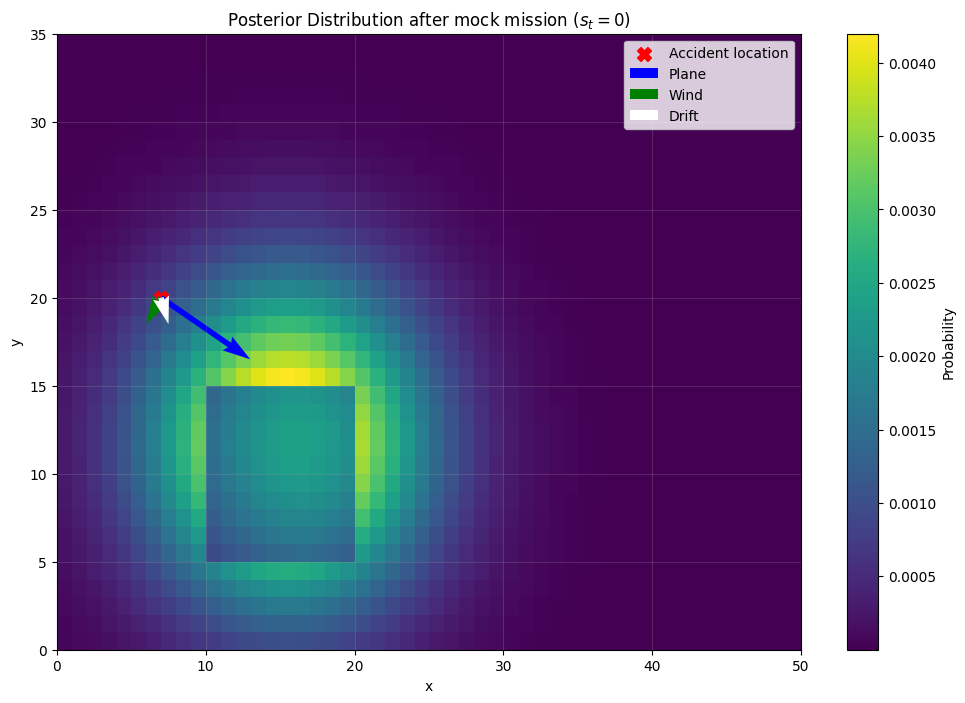

In [5]:
# Initialize posterior as prior
grid_df['posterior'] = grid_df['prior'].copy()

def update_posterior(df, x_min, x_max, y_min, y_max, effort, outcome_st):
    df_copy = df.copy()
    
    # 1. Calculate c_tj
    c_tj = ((df_copy['x'] >= x_min) & (df_copy['x'] <= x_max) & 
            (df_copy['y'] >= y_min) & (df_copy['y'] <= y_max)).astype(int)
    
    # 2. Calculate rho_tj
    rho_tj = detection_probability(effort, df_copy['depth'], df_copy['roughness'])
    
    # 3. Calculate q_tj
    q_tj = c_tj * rho_tj
    
    # 4. Bayesian Update
    if outcome_st == 0:
        likelihood = 1 - q_tj
    elif outcome_st == 1:
        likelihood = q_tj
    else:
        raise ValueError("Outcome must be 0 or 1")
        
    df_copy['posterior'] = df_copy['posterior'] * likelihood
    
    # 5. Normalize
    df_copy['posterior'] = df_copy['posterior'] / df_copy['posterior'].sum()
    
    return df_copy

# Simulate a mock failed mission in the center to see how posterior updates
mock_x_min, mock_x_max = 10, 20
mock_y_min, mock_y_max = 5, 15
mock_effort = 2.0
mock_outcome = 0 # Not found

grid_df_updated = update_posterior(grid_df, mock_x_min, mock_x_max, mock_y_min, mock_y_max, mock_effort, mock_outcome)

plot_heatmap(grid_df_updated, 'posterior', "Posterior Distribution after mock mission ($s_t = 0$)")


## Task 4: Next Search Mission

To propose a new search mission, we want to maximize the probability of finding the object while respecting a theoretical budget constraint.
A simple heuristic is to find the rectangular region with the highest posterior probability mass, sized according to how much budget/effort we want to spend.

For demonstration, we will identify the cell with the maximum posterior probability and propose a 10x10 cell search window around it.


In [6]:
def propose_next_mission(df, window_size_x=10, window_size_y=10):
    # Find the cell with maximum posterior
    max_idx = df['posterior'].idxmax()
    center_x = df.loc[max_idx, 'x']
    center_y = df.loc[max_idx, 'y']
    
    # Define bounds centered around the peak
    x_min = max(0, center_x - window_size_x / 2)
    x_max = min(Nx, center_x + window_size_x / 2)
    y_min = max(0, center_y - window_size_y / 2)
    y_max = min(Ny, center_y + window_size_y / 2)
    
    # Calculate total probability mass in this region
    mask = (df['x'] >= x_min) & (df['x'] <= x_max) & (df['y'] >= y_min) & (df['y'] <= y_max)
    prob_mass = df.loc[mask, 'posterior'].sum()
    
    print(f"Proposed Mission Area:")
    print(f"x: [{x_min}, {x_max}]")
    print(f"y: [{y_min}, {y_max}]")
    print(f"Probability mass contained: {prob_mass:.4f}")
    
    return x_min, x_max, y_min, y_max

print("For the initial prior:")
propose_next_mission(grid_df)

print("\nFor the updated posterior (after mock mission):")
propose_next_mission(grid_df_updated)


For the initial prior:
Proposed Mission Area:
x: [10.5, 20.5]
y: [6.5, 16.5]
Probability mass contained: 0.3944

For the updated posterior (after mock mission):
Proposed Mission Area:
x: [10.5, 20.5]
y: [10.5, 20.5]
Probability mass contained: 0.3009


(10.5, 20.5, 10.5, 20.5)

## Task 5: Discussion

**Main strengths of the model:**
- Uses all physical vectors mathematically consistently by deriving an expected path.
- Detection model ($
ho_{tj}$) is continuous and naturally accommodates strictly bounded probabilities in $[0,1)$, while scaling intuitively with environmental factors.

**Main limitations:**
- The weights for the vectors and uncertainty matrix are heuristically chosen based on vague witness statements.
- The cost function is linear, and this heuristic selection algorithm does not exhaustively optimize the detection/cost ratio globally.

**Improvements with more information:**
- If we had precise timings or velocity confidence intervals, we could simulate exact drift Monte Carlo trajectories to build the prior, rather than just using a simple Gaussian approach.
